In [7]:
!pip install pandas nltk textblob wordcloud matplotlib seaborn

In [8]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

import re

In [9]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
data = {
    "Review": [
        "The room was clean and spacious. Staff were very friendly.",
        "Terrible food and dirty bathroom. Very disappointed.",
        "Excellent service and comfortable bed. Loved the stay.",
        "The AC was not working and the room smelled bad.",
        "Amazing breakfast and polite staff.",
        "The swimming pool was dirty and food was cold.",
        "Great location and clean rooms.",
        "Very noisy room. Could not sleep at night.",
        "Helpful staff and excellent facilities.",
        "Poor housekeeping and rude receptionist.",
        "Fantastic experience. Everything was perfect.",
        "The WiFi was slow and bathroom was unclean.",
        "Nice hotel with delicious food.",
        "Reception service was excellent.",
        "Parking area was small but room was comfortable."
    ]
}

df = pd.DataFrame(data)

df.head()

,Review
0,The room was clean and spacious. Staff were ve...
1,Terrible food and dirty bathroom. Very disappo...
2,Excellent service and comfortable bed. Loved t...
3,The AC was not working and the room smelled bad.
4,Amazing breakfast and polite staff.


In [11]:
import nltk
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(preprocess)

df.head()

,Review,Cleaned_Review
0,The room was clean and spacious. Staff were ve...,room clean spacious staff friendly
1,Terrible food and dirty bathroom. Very disappo...,terrible food dirty bathroom disappointed
2,Excellent service and comfortable bed. Loved t...,excellent service comfortable bed loved stay
3,The AC was not working and the room smelled bad.,ac working room smelled bad
4,Amazing breakfast and polite staff.,amazing breakfast polite staff


In [12]:
def get_sentiment(review):

    score = TextBlob(review).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df

,Review,Cleaned_Review,Sentiment
0,The room was clean and spacious. Staff were ve...,room clean spacious staff friendly,Positive
1,Terrible food and dirty bathroom. Very disappo...,terrible food dirty bathroom disappointed,Negative
2,Excellent service and comfortable bed. Loved t...,excellent service comfortable bed loved stay,Positive
3,The AC was not working and the room smelled bad.,ac working room smelled bad,Negative
4,Amazing breakfast and polite staff.,amazing breakfast polite staff,Positive
5,The swimming pool was dirty and food was cold.,swimming pool dirty food cold,Negative
6,Great location and clean rooms.,great location clean room,Positive
7,Very noisy room. Could not sleep at night.,noisy room could sleep night,Neutral
8,Helpful staff and excellent facilities.,helpful staff excellent facility,Positive
9,Poor housekeeping and rude receptionist.,poor housekeeping rude receptionist,Negative


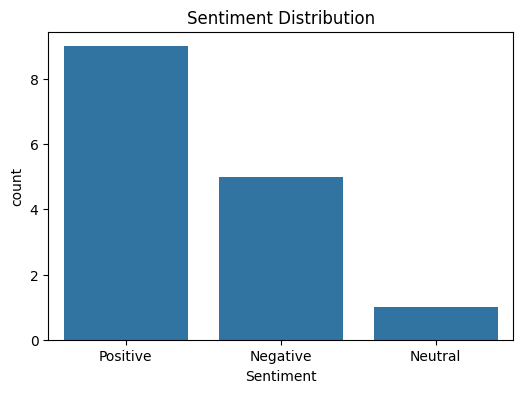

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")

plt.show()

In [14]:
issue_keywords = {
    "Room":["room","bed","ac","bathroom"],
    "Food":["food","breakfast"],
    "Staff":["staff","receptionist","service"],
    "Cleanliness":["dirty","clean","unclean","housekeeping"],
    "Amenities":["wifi","pool","parking","facility"]
}

In [15]:
def identify_issue(review):

    found=[]

    review=review.lower()

    for category, words in issue_keywords.items():

        for word in words:

            if word in review:

                found.append(category)
                break

    if len(found)==0:
        return "Other"

    return ", ".join(found)

df["Issue_Category"]=df["Review"].apply(identify_issue)

df

,Review,Cleaned_Review,Sentiment,Issue_Category
0,The room was clean and spacious. Staff were ve...,room clean spacious staff friendly,Positive,"Room, Staff, Cleanliness"
1,Terrible food and dirty bathroom. Very disappo...,terrible food dirty bathroom disappointed,Negative,"Room, Food, Cleanliness"
2,Excellent service and comfortable bed. Loved t...,excellent service comfortable bed loved stay,Positive,"Room, Staff"
3,The AC was not working and the room smelled bad.,ac working room smelled bad,Negative,Room
4,Amazing breakfast and polite staff.,amazing breakfast polite staff,Positive,"Food, Staff"
5,The swimming pool was dirty and food was cold.,swimming pool dirty food cold,Negative,"Food, Cleanliness, Amenities"
6,Great location and clean rooms.,great location clean room,Positive,"Room, Cleanliness"
7,Very noisy room. Could not sleep at night.,noisy room could sleep night,Neutral,Room
8,Helpful staff and excellent facilities.,helpful staff excellent facility,Positive,"Room, Staff"
9,Poor housekeeping and rude receptionist.,poor housekeeping rude receptionist,Negative,"Staff, Cleanliness"


In [16]:
negative_reviews=df[df["Sentiment"]=="Negative"]

negative_reviews

,Review,Cleaned_Review,Sentiment,Issue_Category
1,Terrible food and dirty bathroom. Very disappo...,terrible food dirty bathroom disappointed,Negative,"Room, Food, Cleanliness"
3,The AC was not working and the room smelled bad.,ac working room smelled bad,Negative,Room
5,The swimming pool was dirty and food was cold.,swimming pool dirty food cold,Negative,"Food, Cleanliness, Amenities"
9,Poor housekeeping and rude receptionist.,poor housekeeping rude receptionist,Negative,"Staff, Cleanliness"
11,The WiFi was slow and bathroom was unclean.,wifi slow bathroom unclean,Negative,"Room, Cleanliness, Amenities"


In [17]:
issue_count={}

for issues in df["Issue_Category"]:

    for issue in issues.split(", "):

        issue_count[issue]=issue_count.get(issue,0)+1

issue_df=pd.DataFrame(issue_count.items(),columns=["Issue","Count"])

issue_df

,Issue,Count
0,Room,9
1,Staff,6
2,Cleanliness,6
3,Food,4
4,Amenities,3
5,Other,1


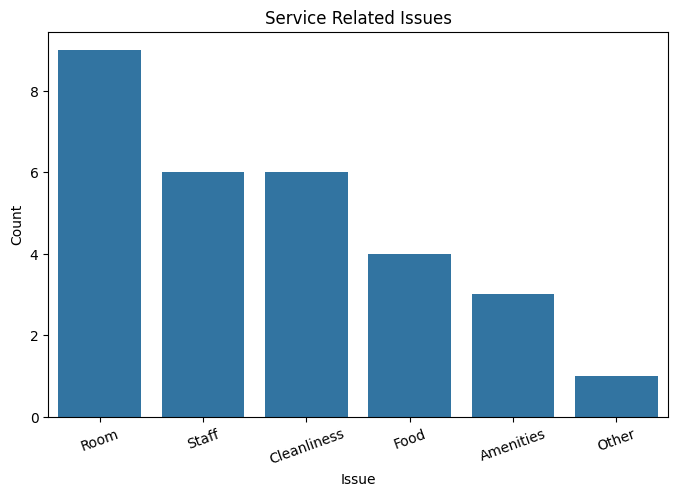

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(x="Issue",y="Count",data=issue_df)

plt.title("Service Related Issues")

plt.xticks(rotation=20)

plt.show()

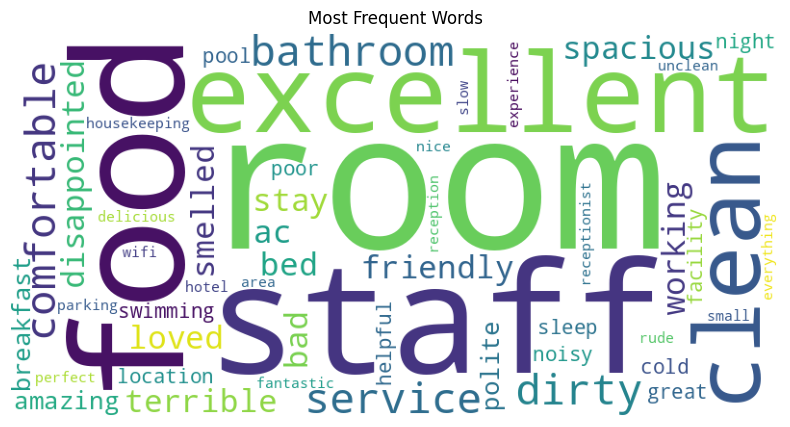

In [19]:
text=" ".join(df["Cleaned_Review"])

wordcloud=WordCloud(width=800,height=400,
                    background_color="white").generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.show()

In [20]:
total_reviews=len(df)

positive=len(df[df["Sentiment"]=="Positive"])

negative=len(df[df["Sentiment"]=="Negative"])

neutral=len(df[df["Sentiment"]=="Neutral"])

print("="*40)
print(" HOTEL CUSTOMER SATISFACTION REPORT ")
print("="*40)

print("Total Reviews :",total_reviews)

print("Positive Reviews :",positive)

print("Negative Reviews :",negative)

print("Neutral Reviews :",neutral)

satisfaction=(positive/total_reviews)*100

print("\nCustomer Satisfaction :",round(satisfaction,2),"%")

print("\nMost Common Issues:")

print(issue_df.sort_values(by="Count",ascending=False))

 HOTEL CUSTOMER SATISFACTION REPORT 
Total Reviews : 15
Positive Reviews : 9
Negative Reviews : 5
Neutral Reviews : 1

Customer Satisfaction : 60.0 %

Most Common Issues:
         Issue  Count
0         Room      9
1        Staff      6
2  Cleanliness      6
3         Food      4
4    Amenities      3
5        Other      1


In [21]:
df.to_csv("Hotel_Review_Analysis.csv",index=False)

print("Results saved successfully.")

Results saved successfully.
